In [1]:
import h3
import numpy as np
import pandas as pd
from tqdm import tqdm
from pathlib import Path
from collections import Counter
import geopandas as gpd
from shapely.geometry import Point

# Visualization
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

# Machine learning & embeddings
from sklearn.manifold import TSNE
import umap.umap_ as umap
from gensim.models import Word2Vec

DATA_DIR = Path('/Users/wenlanzhang/Downloads/PhD_UCL/Data/Netmob2025/')

In [ ]:
import pandas as pd
from tqdm import tqdm
import ollama
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import pandas as pd

# Load data

## Individual 

In [29]:
individuals = pd.read_csv(DATA_DIR/'data/individuals_dataset.csv')

# individuals.columns

# len(individuals['PRO_CAT'].unique()) 8
# individuals['PRO_CAT'].unique() 
individuals

,ID,CODGEO,AREA_NAME,SEX,AGE,DIPLOMA,PRO_CAT,TYPE_HOUSE,NBPERS_HOUSE,NB_10,...,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
0,10_2978,78092,Bougival,Woman,41,NaN,4,In a couple with child(ren),2,1,...,1,2,0,False,False,False,False,False,1856.206160,True
1,10_2980,75120,Paris,Man,30,5-year-and-above higher education degree: Mast...,2,Living alone,1,0,...,0,0,0,True,False,False,False,False,1375.000372,True
2,10_2981,91326,Juvisy-sur-Orge,Man,38,5-year-and-above higher education degree: Mast...,2,In a couple without children,2,0,...,0,1,0,True,False,False,False,False,1231.812990,True
3,10_2982,91573,Saint-Pierre-du-Perray,Man,43,"3–4-year higher education degree: Licence, Pro...",2,Single parent (divorced / separated / widowed),1,1,...,0,2,0,True,False,False,False,False,426.311616,True
4,10_2984,78073,Bois-d'Arcy,Woman,39,5-year-and-above higher education degree: Mast...,2,Living alone,1,0,...,0,1,0,True,False,False,True,False,843.194726,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3332,7_2972,95127,Cergy,Woman,59,5-year-and-above higher education degree: Mast...,2,In a couple without children,1,0,...,0,0,0,False,False,False,False,False,608.890788,True
3333,7_2973,91461,Ollainville,Woman,42,NaN,2,In a couple with child(ren),5,1,...,0,2,0,False,False,False,False,False,786.094977,True
3334,7_2974,91534,Saclay,Man,52,"3–4-year higher education degree: Licence, Pro...",2,In a couple with child(ren),3,0,...,0,2,0,False,False,False,False,False,1819.688178,True
3335,7_2975,91573,Saint-Pierre-du-Perray,Woman,58,NaN,4,In a couple with child(ren),4,0,...,0,0,0,True,False,False,False,False,962.525230,True


In [28]:
id_to_procat = individuals.set_index('ID')['PRO_CAT'].to_dict()
id_to_procat

{'10_2978': 4,
 '10_2980': 2,
 '10_2981': 2,
 '10_2982': 2,
 '10_2984': 2,
 '10_2987': 7,
 '10_2988': 1,
 '10_2989': 3,
 '10_2990': 8,
 '10_2991': 6,
 '10_2992': 2,
 '10_2993': 4,
 '10_2994': 2,
 '10_2995': 1,
 '10_2996': 2,
 '10_2998': 2,
 '10_3000': 7,
 '10_3002': 6,
 '10_3003': 7,
 '10_3004': 2,
 '10_3005': 7,
 '10_3006': 2,
 '10_3007': 6,
 '10_3010': 6,
 '10_3011': 3,
 '10_3014': 4,
 '10_3016': 2,
 '10_3017': 2,
 '10_3018': 4,
 '10_3019': 8,
 '10_3021': 3,
 '10_3022': 2,
 '10_3023': 3,
 '10_3024': 7,
 '10_3025': 2,
 '10_3026': 4,
 '10_3027': 7,
 '10_3030': 2,
 '10_3031': 6,
 '10_3032': 7,
 '10_3033': 3,
 '10_3034': 2,
 '10_3035': 3,
 '10_3036': 4,
 '10_3037': 7,
 '10_3038': 4,
 '10_3039': 5,
 '10_3040': 4,
 '10_3041': 2,
 '10_3042': 2,
 '10_3043': 2,
 '10_3044': 8,
 '10_3047': 2,
 '10_3049': 2,
 '10_3050': 3,
 '10_3052': 7,
 '10_3053': 2,
 '10_3054': 5,
 '10_3055': 2,
 '10_3056': 3,
 '10_3057': 2,
 '10_3058': 2,
 '10_3059': 2,
 '10_3060': 3,
 '10_3063': 2,
 '10_3064': 2,
 '10_3065'

## Trips 

In [3]:
trips = pd.read_csv(DATA_DIR/'data/trips_dataset.csv')
trips = trips[(trips['ID_Trip_Days'] != 'No_Trip') & (trips['ID_Trip_Days'] != 'No_Traces')]

# Sort by individual, date, and trip order
trips = trips.sort_values(by=['ID', 'Date_EMG', 'ID_Trip_Days'])

# len(trips['Area_D'].unique())
# trips.columns
trips

,KEY,ID,Day_EMG,Date_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,...,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
35298,10_2978-wednesday-45000-1,10_2978,wednesday,2023-03-15,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,15.0,DEPART_HOME,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683
35299,10_2978-wednesday-45000-2,10_2978,wednesday,2023-03-15,Normal,2,Internal,BOUGIVAL,BOUGIVAL,78092,...,11.0,OTHER,RETURN_HOME,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683
35300,10_2978-wednesday-45000-3,10_2978,wednesday,2023-03-15,Normal,3,Internal,BOUGIVAL,LE CHESNAY,78092,...,15.0,DEPART_HOME,ACCOM,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683
35301,10_2978-wednesday-45000-4,10_2978,wednesday,2023-03-15,Normal,4,Internal,LE CHESNAY,BOUGIVAL,78158,...,14.0,ACCOM,RETURN_HOME,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683
35302,10_2978-thursday-45001-1,10_2978,thursday,2023-03-16,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,5.0,DEPART_HOME,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,218.345882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64377,7_2976-wednesday-44972-2,7_2976,wednesday,2023-02-15,Normal,2,Internal,IVRY-SUR-SEINE,VITRY-SUR-SEINE,94041,...,20.0,WORK,RETURN_HOME,ELECT_SCOOTER,ELECT_SCOOTER,NaN,NaN,NaN,NaN,67.357451
64379,7_2976-friday-44974-1,7_2976,friday,2023-02-17,Normal,1,Internal,VITRY-SUR-SEINE,SAINT-AUBIN,94081,...,90.0,DEPART_HOME,WORK,BUS,BUS,NaN,NaN,NaN,NaN,67.548807
64380,7_2976-friday-44974-2,7_2976,friday,2023-02-17,Normal,2,Internal,SAINT-AUBIN,VITRY-SUR-SEINE,91538,...,90.0,WORK,RETURN_HOME,BUS,BUS,NaN,NaN,NaN,NaN,67.548807
64381,7_2976-saturday-44975-1,7_2976,saturday,2023-02-18,School holiday,1,Internal,VITRY-SUR-SEINE,PARIS-12E-ARRONDISSEMENT,94081,...,40.0,DEPART_HOME,LEISURE,SUBWAY,SUBWAY,NaN,NaN,NaN,NaN,67.905299


# Check the data

In [4]:
len(trips['Area_O'].unique())

# Day_Type: 5 
# Day_EMG: 7
# Area_O: 1089
# Area_D: 1140
# Code_INSEE_O: 1060
# Code_INSEE_D: 1102

1089

In [8]:
trips.columns

Index(['KEY', 'ID', 'Day_EMG', 'Date_EMG', 'Day_Type', 'ID_Trip_Days',
       'Type_Trip_OD', 'Area_O', 'Area_D', 'Code_INSEE_O', 'Code_INSEE_D',
       'Zone_O', 'Zone_D', 'Date_O', 'Time_O', 'Date_D', 'Time_D', 'Duration',
       'Purpose_O', 'Purpose_D', 'Main_Mode', 'Mode_1', 'Mode_2', 'Mode_3',
       'Mode_4', 'Mode_5', 'Weight_Day'],
      dtype='object')

## Trips/person 

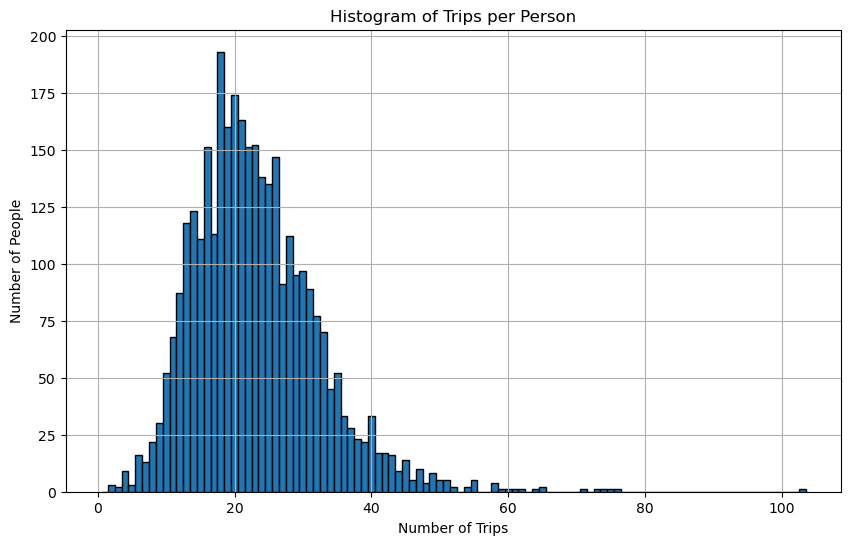

In [5]:
trip_counts = trips['ID'].value_counts()

# Plot a histogram of trips per person
plt.figure(figsize=(10,6))
plt.hist(trip_counts, bins=range(1, trip_counts.max()+2), edgecolor='black', align='left')
plt.title('Histogram of Trips per Person')
plt.xlabel('Number of Trips')
plt.ylabel('Number of People')
plt.grid(True)
plt.show()

## duration/trip 

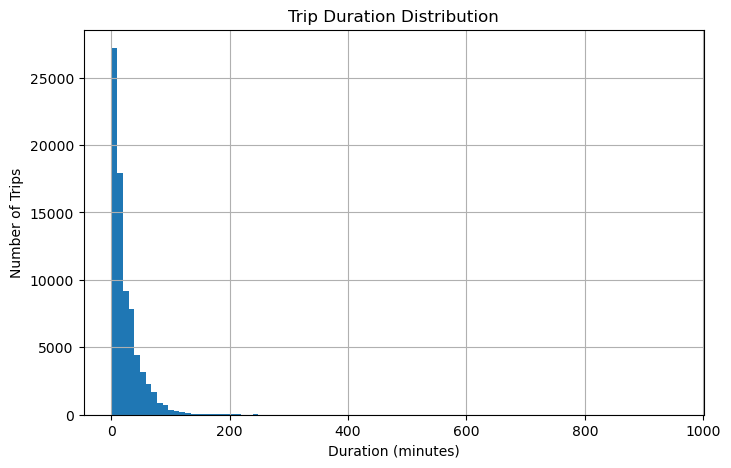

In [6]:
trips['Duration'].hist(bins=100, figsize=(8,5))

plt.title('Trip Duration Distribution')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Trips')
plt.show()

## origin, destination counts

In [5]:
# Count of trips by origin area
origin_counts = trips['Area_O'].value_counts()
print("Top Origin Areas:\n", origin_counts.head(10))

# Count of trips by destination area
destination_counts = trips['Area_D'].value_counts()
print("Top Destination Areas:\n", destination_counts.head(10))

Top Origin Areas:
 Area_O
PARIS-13E-ARRONDISSEMENT    2169
PARIS-12E-ARRONDISSEMENT    2086
PARIS-15E-ARRONDISSEMENT    1711
PARIS-19E-ARRONDISSEMENT    1395
PARIS-14E-ARRONDISSEMENT    1284
PARIS-20E-ARRONDISSEMENT    1236
EVRY                        1192
PARIS-11E-ARRONDISSEMENT    1132
MONTREUIL                   1052
PARIS-18E-ARRONDISSEMENT    1014
Name: count, dtype: int64
Top Destination Areas:
 Area_D
PARIS-13E-ARRONDISSEMENT    2166
PARIS-12E-ARRONDISSEMENT    2081
PARIS-15E-ARRONDISSEMENT    1707
PARIS-19E-ARRONDISSEMENT    1392
PARIS-14E-ARRONDISSEMENT    1284
PARIS-20E-ARRONDISSEMENT    1237
EVRY                        1194
PARIS-11E-ARRONDISSEMENT    1130
MONTREUIL                   1049
PARIS-18E-ARRONDISSEMENT    1019
Name: count, dtype: int64


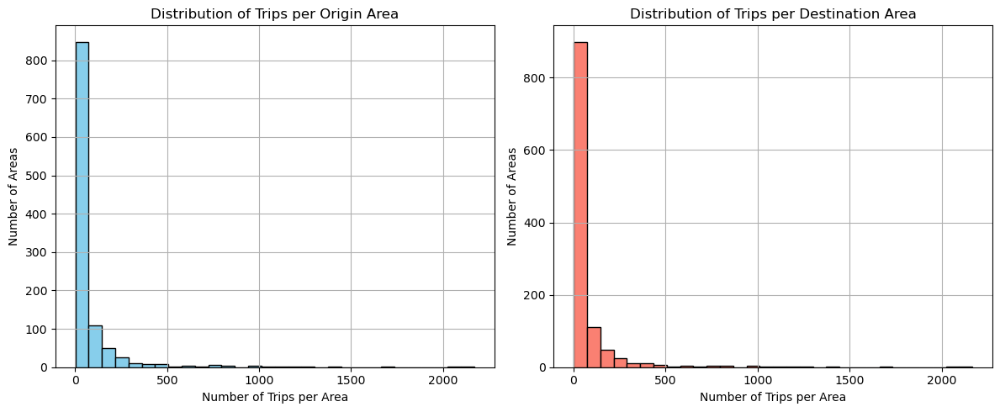

In [6]:
# Get the counts of trips per area for origin and destination
origin_counts = trips['Area_O'].value_counts()
destination_counts = trips['Area_D'].value_counts()

plt.figure(figsize=(12, 5))

# Histogram of origin counts (number of trips per origin area)
plt.subplot(1, 2, 1)
plt.hist(origin_counts, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Trips per Origin Area')
plt.xlabel('Number of Trips per Area')
plt.ylabel('Number of Areas')
plt.grid(True)

# Histogram of destination counts (number of trips per destination area)
plt.subplot(1, 2, 2)
plt.hist(destination_counts, bins=30, color='salmon', edgecolor='black')
plt.title('Distribution of Trips per Destination Area')
plt.xlabel('Number of Trips per Area')
plt.ylabel('Number of Areas')
plt.grid(True)

plt.tight_layout()
plt.show()

# Data Cleaning and Preprocess

## Remove ultra-rare locations (low-frequency O/D)

In [4]:
# Count how many times each Area_O and Area_D appears
origin_counts = trips['Area_O'].value_counts()
destination_counts = trips['Area_D'].value_counts()

# Find areas that appear less than THRESHOLD
THRESHOLD = 5
single_origin_areas = origin_counts[origin_counts <= THRESHOLD].index
single_destination_areas = destination_counts[destination_counts <= THRESHOLD].index

# Filter out rows where BOTH Area_O and Area_D appear only once
filtered_df = trips[
    ~(
        trips['Area_O'].isin(single_origin_areas) | 
        trips['Area_D'].isin(single_destination_areas)
    )]

print(f"Original number of trips: {len(trips)}")
print(f"Number of trips after filtering: {len(filtered_df)}")

print(f"Unique origin areas before filtering: {trips['Area_O'].nunique()}")
print(f"Unique destination areas before filtering: {trips['Area_D'].nunique()}")
print(f"Unique origin areas after filtering: {filtered_df['Area_O'].nunique()}")
print(f"Unique destination areas after filtering: {filtered_df['Area_D'].nunique()}")

Original number of trips: 76968
Number of trips after filtering: 75381
Unique origin areas before filtering: 1088
Unique destination areas before filtering: 1139
Unique origin areas after filtering: 649
Unique destination areas after filtering: 649


## Filter short sequences (e.g. only 1 trip per day)

In [6]:
# Count trips per person per day
trip_counts = filtered_df.groupby(['ID', 'Date_EMG']).size()

# Keep only person-day groups with at least 2 trips
valid_days = trip_counts[trip_counts >= 2].index

# Filter the cleaned dataset
filtered_df = filtered_df.dropna(subset=['Area_O', 'Area_D'])
filtered_df = filtered_df.set_index(['ID', 'Date_EMG'])
filtered_df = filtered_df.loc[filtered_df.index.isin(valid_days)]
filtered_df = filtered_df.reset_index()
filtered_df
# print(f"Original number of trips: {len(trips)}")
# print(f"Number of trips after filtering: {len(filtered_df)}")

,ID,Date_EMG,KEY,Day_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,...,Duration,Purpose_O,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day
0,10_2978,2023-03-15,10_2978-wednesday-45000-1,wednesday,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,15.0,DEPART_HOME,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683
1,10_2978,2023-03-15,10_2978-wednesday-45000-2,wednesday,Normal,2,Internal,BOUGIVAL,BOUGIVAL,78092,...,11.0,OTHER,RETURN_HOME,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683
2,10_2978,2023-03-15,10_2978-wednesday-45000-3,wednesday,Normal,3,Internal,BOUGIVAL,LE CHESNAY,78092,...,15.0,DEPART_HOME,ACCOM,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683
3,10_2978,2023-03-15,10_2978-wednesday-45000-4,wednesday,Normal,4,Internal,LE CHESNAY,BOUGIVAL,78158,...,14.0,ACCOM,RETURN_HOME,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683
4,10_2978,2023-03-16,10_2978-thursday-45001-1,thursday,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,5.0,DEPART_HOME,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,218.345882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74737,7_2976,2023-02-15,7_2976-wednesday-44972-2,wednesday,Normal,2,Internal,IVRY-SUR-SEINE,VITRY-SUR-SEINE,94041,...,20.0,WORK,RETURN_HOME,ELECT_SCOOTER,ELECT_SCOOTER,NaN,NaN,NaN,NaN,67.357451
74738,7_2976,2023-02-17,7_2976-friday-44974-1,friday,Normal,1,Internal,VITRY-SUR-SEINE,SAINT-AUBIN,94081,...,90.0,DEPART_HOME,WORK,BUS,BUS,NaN,NaN,NaN,NaN,67.548807
74739,7_2976,2023-02-17,7_2976-friday-44974-2,friday,Normal,2,Internal,SAINT-AUBIN,VITRY-SUR-SEINE,91538,...,90.0,WORK,RETURN_HOME,BUS,BUS,NaN,NaN,NaN,NaN,67.548807
74740,7_2976,2023-02-18,7_2976-saturday-44975-1,saturday,School holiday,1,Internal,VITRY-SUR-SEINE,PARIS-12E-ARRONDISSEMENT,94081,...,40.0,DEPART_HOME,LEISURE,SUBWAY,SUBWAY,NaN,NaN,NaN,NaN,67.905299


# Qwen3

In [11]:
def build_person_summary(df_person):
    # Total trips
    total_trips = len(df_person)
    
    # Locations visited
    all_locations = list(df_person['Area_O']) + list(df_person['Area_D'])
    top_locs = Counter(all_locations).most_common(3)
    loc_summary = ", ".join([f"{loc} ({cnt})" for loc, cnt in top_locs])

    # Day types
    weekday_ratio = (df_person['Day_Type'] == 'Normal').mean()

    # Trip durations
    avg_duration = df_person['Duration'].mean()

    # Purposes
    purposes_o = Counter(df_person['Purpose_O']).most_common(2)
    purposes_d = Counter(df_person['Purpose_D']).most_common(2)

    # Modes
    modes = df_person['Main_Mode'].dropna()
    top_modes = Counter(modes).most_common(2)
    mode_summary = ", ".join([f"{mode} ({cnt})" for mode, cnt in top_modes])

    # Time of day from KEY (optional, or you can add timestamp column)
    # You could parse trip time here if available

    summary = f"This person made {total_trips} trips. "
    summary += f"Most visited locations were: {loc_summary}. "
    
    if weekday_ratio > 0.7:
        summary += "Trips mostly occurred on weekdays. "
    elif weekday_ratio < 0.3:
        summary += "Trips mostly occurred on weekends. "
    else:
        summary += "Trips were spread across weekdays and weekends. "

    summary += f"Average trip duration was around {round(avg_duration)} minutes. "

    if purposes_o:
        summary += "Trip purposes at origin were mainly " + ", ".join([p[0] for p in purposes_o]) + ". "
    if purposes_d:
        summary += "Destinations were often for " + ", ".join([p[0] for p in purposes_d]) + ". "

    if mode_summary:
        summary += f"Preferred travel modes were: {mode_summary}. "

    return summary


In [13]:
summaries = {}

for person_id, group in filtered_df.groupby('ID'):
    summary = build_person_summary(group)
    summaries[person_id] = summary

summaries

{'10_2978': 'This person made 21 trips. Most visited locations were: BOUGIVAL (27), LE CHESNAY (6), NANTERRE (4). Trips mostly occurred on weekdays. Average trip duration was around 22 minutes. Trip purposes at origin were mainly DEPART_HOME, OTHER. Destinations were often for RETURN_HOME, OTHER. Preferred travel modes were: WALKING (11), PRIV_CAR_DRIVER (10). ',
 '10_2980': 'This person made 23 trips. Most visited locations were: PARIS-20E-ARRONDISSEMENT (26), PARIS-10E-ARRONDISSEMENT (14), PARIS-4E-ARRONDISSEMENT (2). Trips mostly occurred on weekdays. Average trip duration was around 19 minutes. Trip purposes at origin were mainly DEPART_HOME, WORK. Destinations were often for RETURN_HOME, WORK. Preferred travel modes were: WALKING (10), SUBWAY (8). ',
 '10_2981': 'This person made 19 trips. Most visited locations were: JUVISY-SUR-ORGE (28), REAU (4), COULOMMIERS (4). Trips mostly occurred on weekdays. Average trip duration was around 28 minutes. Trip purposes at origin were mainly 

In [15]:
# Define the embedding model you pulled
EMBEDDING_MODEL = 'dengcao/Qwen3-Embedding-8B:Q5_K_M' # Or 4B, 0.6B

def get_sentence_embedding(text: str) -> list[float]:
    """Generates a numerical embedding vector for a given text."""
    try:
        # The 'embeddings' endpoint is specifically for this purpose
        response = ollama.embeddings(
            model=EMBEDDING_MODEL,
            prompt=text # Pass the sentence as the prompt
        )
        return response['embedding']
    except Exception as e:
        print(f"Error generating embedding for '{text}': {e}")
        return []

In [17]:
embeddings = {}

for person_id, text in tqdm(summaries.items(), desc="Generating embeddings"):
    vec = get_sentence_embedding(text)
    embeddings[person_id] = vec

Generating embeddings: 100%|████████████████| 3329/3329 [33:54<00:00,  1.64it/s]


In [19]:
embeddings['2_1964']

[2.5888984203338623,
 2.7172183990478516,
 -1.0836859941482544,
 0.3453752100467682,
 -0.7518786191940308,
 0.9948654174804688,
 0.5131939053535461,
 -0.5311131477355957,
 -0.4097636044025421,
 -0.055780380964279175,
 0.4246118366718292,
 2.008847713470459,
 6.263719081878662,
 -0.7293676137924194,
 -1.2182927131652832,
 0.4546408951282501,
 -3.2180275917053223,
 0.5661921501159668,
 1.8277825117111206,
 2.2563154697418213,
 1.790495753288269,
 -2.164010524749756,
 -0.1443513035774231,
 -0.9215395450592041,
 -2.111710548400879,
 0.01971164159476757,
 2.3762855529785156,
 -2.201826810836792,
 1.1284619569778442,
 2.025801181793213,
 -0.0874534398317337,
 -2.076084852218628,
 2.474138021469116,
 4.722832202911377,
 0.6800031065940857,
 -0.8526142835617065,
 -2.17881441116333,
 1.0522267818450928,
 -1.0660496950149536,
 -2.7935056686401367,
 -2.3646886348724365,
 -0.40131834149360657,
 -3.908029556274414,
 0.1752338409423828,
 1.860338568687439,
 0.6324222683906555,
 -1.9555851221084595,


# Visulise

In [21]:
# Convert to DataFrame
embedding_df = pd.DataFrame.from_dict(embeddings, orient='index')
embedding_df.index.name = 'ID'
embedding_df.reset_index(inplace=True)
embedding_df

,ID,0,1,2,3,4,5,6,7,8,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,10_2978,3.209680,1.694845,0.357643,1.038738,-0.069276,-0.182639,-0.752040,-0.863631,0.256926,...,-0.461768,0.726128,0.198640,2.013299,1.717281,1.634712,-0.166872,1.156094,-0.085718,3.231686
1,10_2980,1.659188,2.671609,-0.861626,0.691245,-1.107546,-0.020674,0.290807,-1.412654,-0.396484,...,-1.627967,0.590918,0.602349,2.876440,1.973209,2.276360,-0.031540,0.348435,-0.270867,3.616902
2,10_2981,2.463641,1.432686,-0.461972,1.447319,-2.178120,-1.108092,-0.018442,-0.759190,0.419027,...,0.009981,0.776740,0.848669,2.496010,2.193198,1.521868,-1.072558,1.175806,-0.552982,3.314168
3,10_2982,2.103359,1.622352,0.420344,0.643925,-0.766026,-0.913937,-0.409209,-1.449057,-0.303506,...,-0.992642,1.162184,1.282830,1.984882,1.970320,2.437915,-0.962830,0.231545,0.156877,2.592754
4,10_2984,3.328386,3.203251,-0.124916,1.511042,0.911348,-0.915809,-0.323470,-0.513514,-0.330824,...,0.071567,1.310495,0.795538,2.281777,1.288309,1.154440,0.222378,1.454823,-0.372844,1.710296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3324,7_2972,2.181659,2.129326,0.258759,0.958529,-0.801324,-0.286714,-0.435407,-0.423883,1.137680,...,-0.827738,1.621706,1.001164,2.443820,3.155386,0.239869,-0.504181,2.281589,-0.095490,4.785901
3325,7_2973,0.772576,2.198413,0.428982,0.877559,0.545436,-0.905869,-1.709802,0.695299,0.781810,...,-0.082905,2.540497,-0.037085,0.649091,1.562901,0.259534,-0.064989,1.290348,-0.355196,4.032119
3326,7_2974,2.690176,0.993264,0.842763,0.890616,-2.414539,-0.785757,0.236813,-0.509314,0.449993,...,-1.531732,0.702786,0.910298,1.420429,2.449781,2.074163,-1.336601,1.204853,-0.204826,4.004636
3327,7_2975,2.717443,0.711549,-0.428268,1.385836,-2.040129,-0.918060,0.190515,-1.253444,-0.542688,...,-1.022235,0.921710,2.279951,1.399629,1.879529,2.014017,-1.309856,0.816245,-0.730519,3.248048


## Option A: Using UMAP

/opt/miniconda3/envs/geo_env_LLM/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


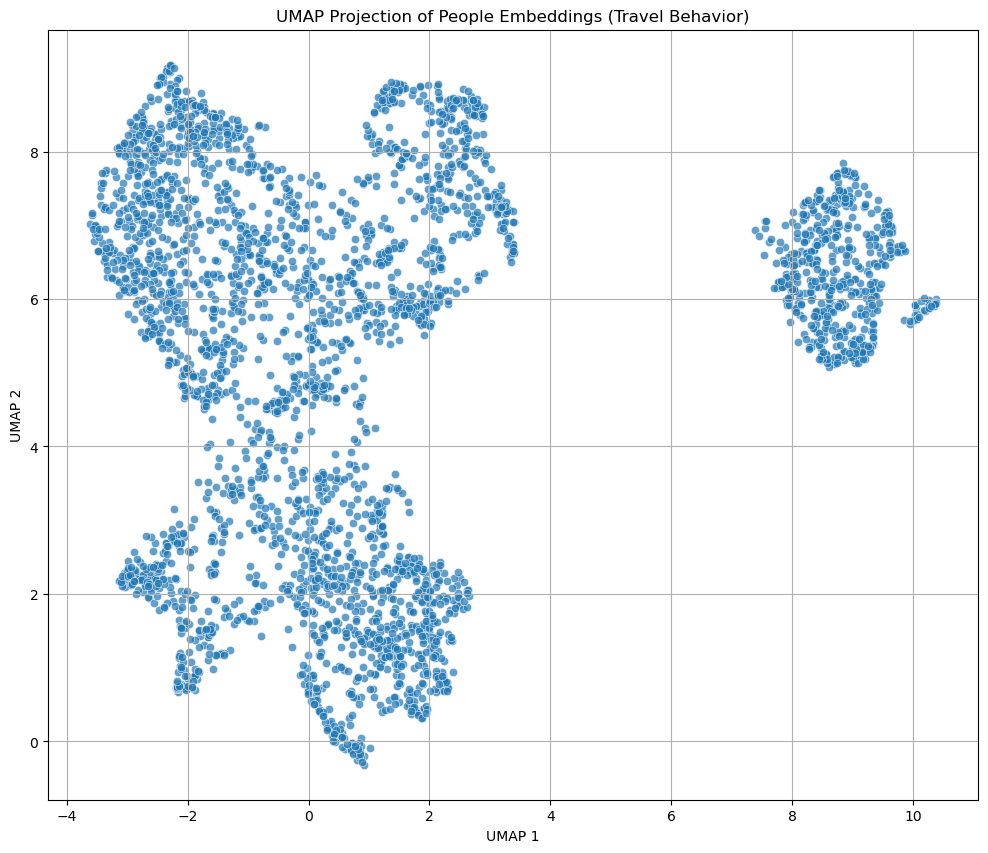

In [22]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Reduce to 2D
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding_2d = reducer.fit_transform(embedding_df.drop(columns='ID'))

# Add to DataFrame
embedding_df['X'] = embedding_2d[:, 0]
embedding_df['Y'] = embedding_2d[:, 1]

# Plot
plt.figure(figsize=(12, 10))
sns.scatterplot(data=embedding_df, x='X', y='Y', alpha=0.7)
plt.title('UMAP Projection of People Embeddings (Travel Behavior)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()


## Option B: Using t-SNE

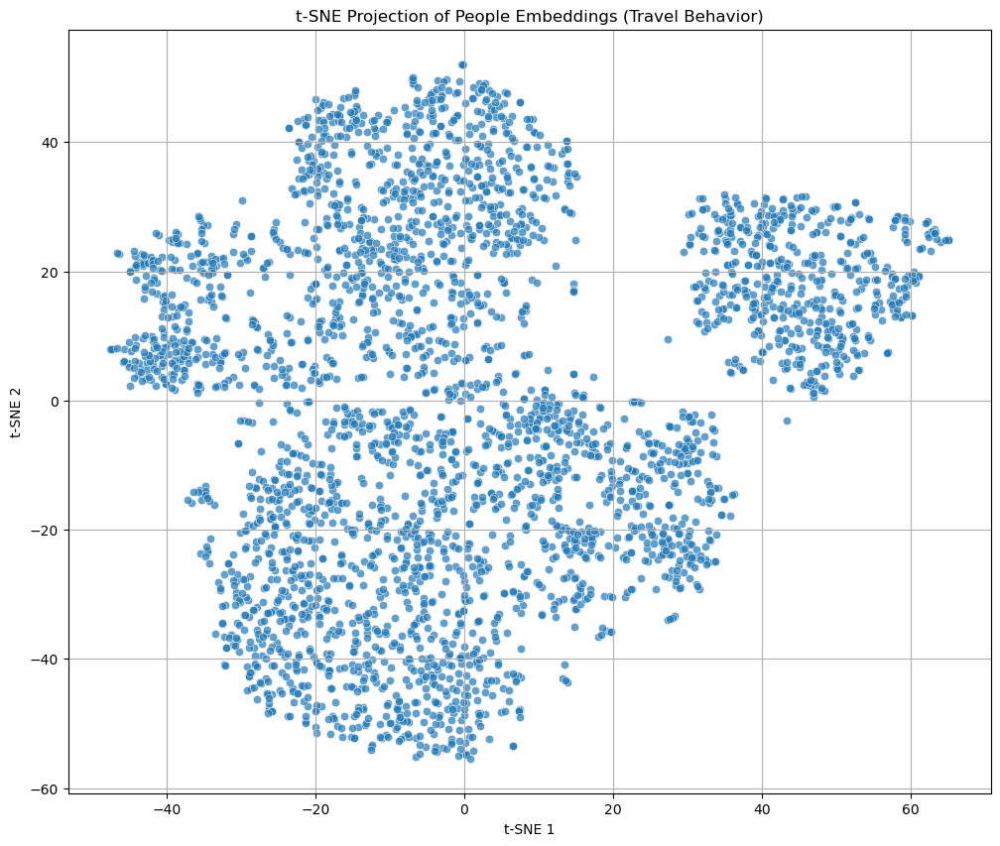

In [26]:
# Step 1: Keep only the embedding columns (exclude 'ID')
X = embedding_df.drop(columns='ID')

# Step 2: Convert column names to strings
X.columns = X.columns.astype(str)

# Step 3: Run t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embedding_2d = tsne.fit_transform(X)

# Step 4: Add back the results to the DataFrame
embedding_df['X'] = embedding_2d[:, 0]
embedding_df['Y'] = embedding_2d[:, 1]

# Step 5: Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.scatterplot(data=embedding_df, x='X', y='Y', alpha=0.7)
plt.title('t-SNE Projection of People Embeddings (Travel Behavior)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True)
plt.show()

## Color

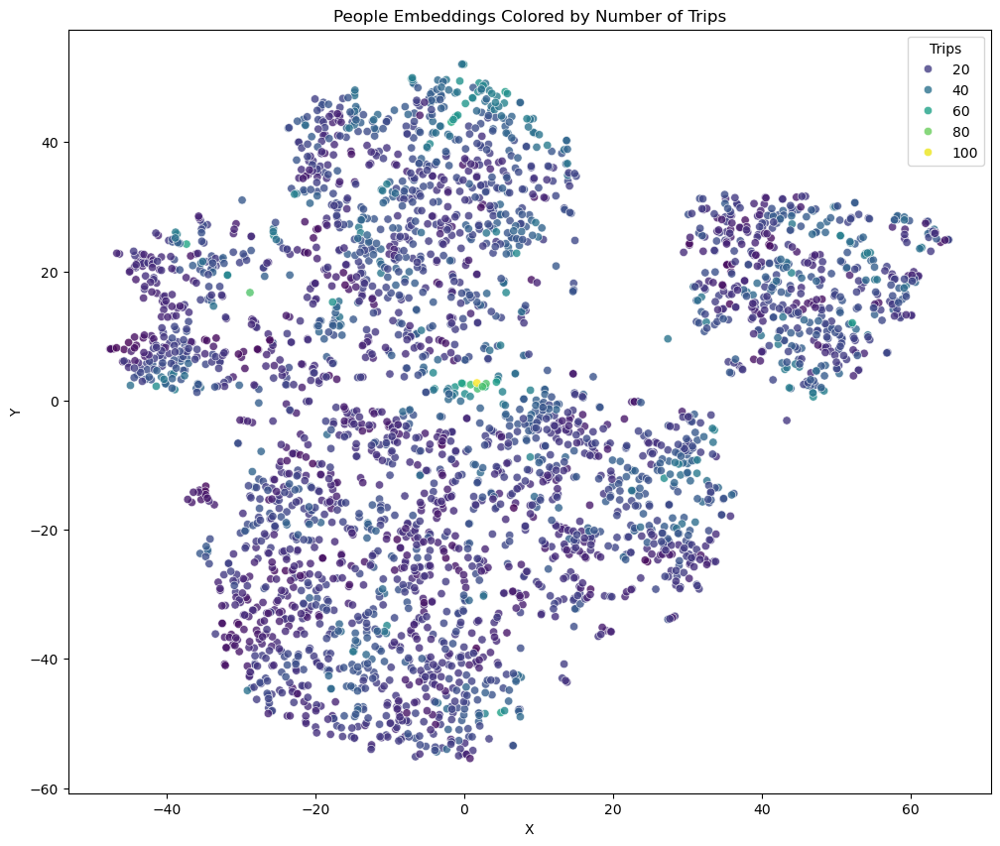

In [27]:
# Example: Add trip count per person
trip_counts = filtered_df['ID'].value_counts()
embedding_df['Num_Trips'] = embedding_df['ID'].map(trip_counts)

# Color points by number of trips
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=embedding_df, x='X', y='Y',
    hue='Num_Trips', palette='viridis', alpha=0.8
)
plt.title('People Embeddings Colored by Number of Trips')
plt.legend(title='Trips')
plt.show()


In [32]:
merged_df = embedding_df.merge(individuals, on='ID', how='left')
merged_df

,ID,0,1,2,3,4,5,6,7,8,...,TWO_WHEELER,BIKE,ELECT_SCOOTER,NAVIGO_SUB,IMAGINER_SUB,OTHER_SUB_PT,BIKE_SUB,NSM_SUB,WEIGHT_INDIV,GPS_RECORD
0,10_2978,3.209680,1.694845,0.357643,1.038738,-0.069276,-0.182639,-0.752040,-0.863631,0.256926,...,1,2,0,False,False,False,False,False,1856.206160,True
1,10_2980,1.659188,2.671609,-0.861626,0.691245,-1.107546,-0.020674,0.290807,-1.412654,-0.396484,...,0,0,0,True,False,False,False,False,1375.000372,True
2,10_2981,2.463641,1.432686,-0.461972,1.447319,-2.178120,-1.108092,-0.018442,-0.759190,0.419027,...,0,1,0,True,False,False,False,False,1231.812990,True
3,10_2982,2.103359,1.622352,0.420344,0.643925,-0.766026,-0.913937,-0.409209,-1.449057,-0.303506,...,0,2,0,True,False,False,False,False,426.311616,True
4,10_2984,3.328386,3.203251,-0.124916,1.511042,0.911348,-0.915809,-0.323470,-0.513514,-0.330824,...,0,1,0,True,False,False,True,False,843.194726,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3324,7_2972,2.181659,2.129326,0.258759,0.958529,-0.801324,-0.286714,-0.435407,-0.423883,1.137680,...,0,0,0,False,False,False,False,False,608.890788,True
3325,7_2973,0.772576,2.198413,0.428982,0.877559,0.545436,-0.905869,-1.709802,0.695299,0.781810,...,0,2,0,False,False,False,False,False,786.094977,True
3326,7_2974,2.690176,0.993264,0.842763,0.890616,-2.414539,-0.785757,0.236813,-0.509314,0.449993,...,0,2,0,False,False,False,False,False,1819.688178,True
3327,7_2975,2.717443,0.711549,-0.428268,1.385836,-2.040129,-0.918060,0.190515,-1.253444,-0.542688,...,0,0,0,True,False,False,False,False,962.525230,True


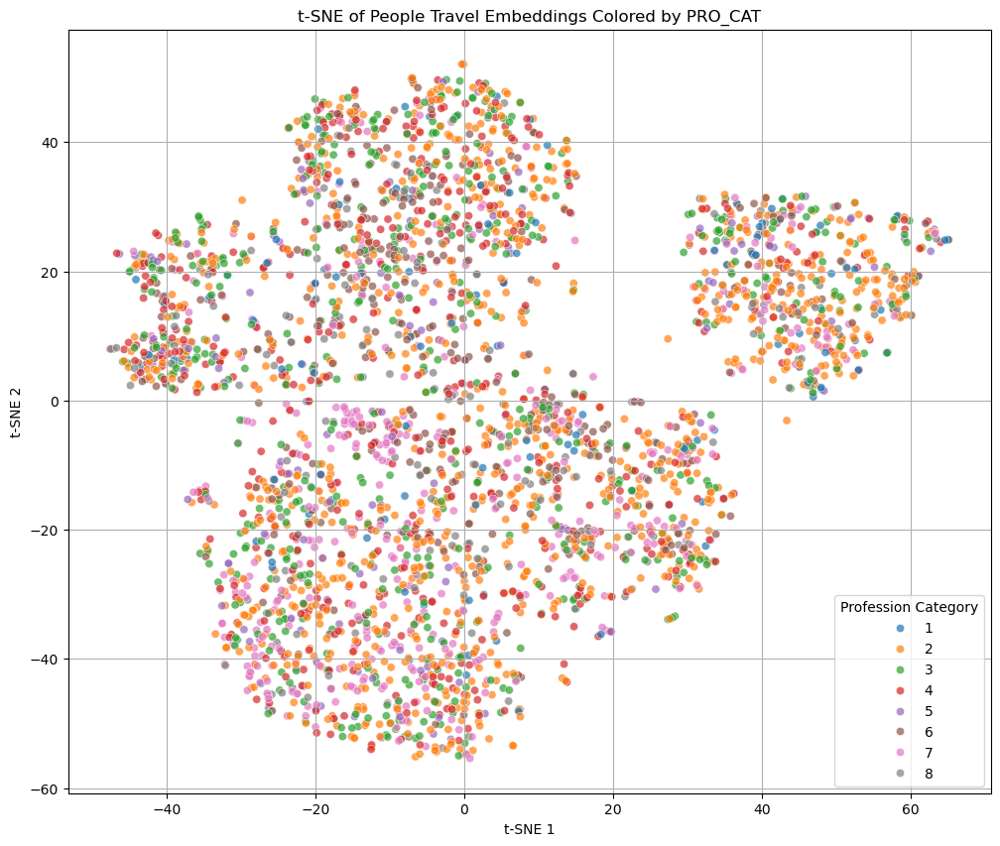

In [33]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=merged_df,
    x='X', y='Y',
    hue='PRO_CAT',       # Change to AGE, SEX, etc. as you like
    palette='tab10',     # or 'viridis' for continuous vars like AGE
    alpha=0.7
)
plt.title('t-SNE of People Travel Embeddings Colored by PRO_CAT')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Profession Category')
plt.grid(True)
plt.show()


In [34]:
import plotly.express as px

fig = px.scatter(
    merged_df,
    x='X', y='Y',
    color='AGE',                # or PRO_CAT
    hover_data=['ID', 'SEX', 'PRO_CAT', 'AGE'],
    title='t-SNE of People Embeddings Colored by AGE'
)
fig.show()


In [36]:
import plotly.express as px

# Merge embedding + individual metadata if not already done
# merged_df = embedding_df.merge(individuals_df, on='ID', how='left')
merged_df['PRO_CAT'] = merged_df['PRO_CAT'].astype(str)  # Convert numbers to strings to treat as categories

fig = px.scatter(
    merged_df,
    x='X', y='Y',
    color='PRO_CAT',  # Can be 'AGE', 'SEX', etc.
    hover_data={
        'ID': True,
        'AGE': True,
        'SEX': True,
        'PRO_CAT': True,
        'TYPE_HOUSE': True,
        'DIPLOMA': True,
    },
    title='t-SNE of People Travel Embeddings Colored by Profession Category (PRO_CAT)',
    labels={'X': 't-SNE 1', 'Y': 't-SNE 2'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    width=1000,
    height=800,
    legend_title='PRO_CAT',
    legend=dict(itemsizing='constant'),
)

fig.show()


# Example

In [7]:
import ollama
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
# Define the embedding model you pulled
EMBEDDING_MODEL = 'dengcao/Qwen3-Embedding-8B:Q5_K_M' # Or 4B, 0.6B

def get_sentence_embedding(text: str) -> list[float]:
    """Generates a numerical embedding vector for a given text."""
    try:
        # The 'embeddings' endpoint is specifically for this purpose
        response = ollama.embeddings(
            model=EMBEDDING_MODEL,
            prompt=text # Pass the sentence as the prompt
        )
        return response['embedding']
    except Exception as e:
        print(f"Error generating embedding for '{text}': {e}")
        return []

In [9]:
# Example sentences
sentences = [
    "The cat sat on the mat.",
    "A feline rested on the rug.",
    "The dog chased the ball in the park.",
    "Artificial intelligence is transforming industries.",
    "Machine learning algorithms power many modern applications."
]

# Get embeddings for each sentence
sentence_embeddings = []
for i, sentence in enumerate(sentences):
    print(f"Generating embedding for sentence {i+1}: '{sentence}'")
    embedding = get_sentence_embedding(sentence)
    if embedding:
        sentence_embeddings.append(np.array(embedding))
        print(f"  Embedding length: {len(embedding)}")
    else:
        sentence_embeddings.append(None)

# Filter out any failed embeddings
valid_embeddings = [emb for emb in sentence_embeddings if emb is not None]
valid_sentences = [sentences[i] for i, emb in enumerate(sentence_embeddings) if emb is not None]

Generating embedding for sentence 1: 'The cat sat on the mat.'
  Embedding length: 4096
Generating embedding for sentence 2: 'A feline rested on the rug.'
  Embedding length: 4096
Generating embedding for sentence 3: 'The dog chased the ball in the park.'
  Embedding length: 4096
Generating embedding for sentence 4: 'Artificial intelligence is transforming industries.'
  Embedding length: 4096
Generating embedding for sentence 5: 'Machine learning algorithms power many modern applications.'
  Embedding length: 4096


In [ ]:
# Calculate and print similarities (e.g., cosine similarity)
if len(valid_embeddings) > 1:
    print("\n--- Semantic Relationships (Cosine Similarity) ---")
    for i in range(len(valid_embeddings)):
        for j in range(i + 1, len(valid_embeddings)):
            sim = cosine_similarity(
                valid_embeddings[i].reshape(1, -1),
                valid_embeddings[j].reshape(1, -1)
            )[0][0]
            print(f"Similarity between '{valid_sentences[i]}' and '{valid_sentences[j]}': {sim:.4f}")


# Preprocess and Build Sequences

| Concept        | Description                                         | Example                           |
| -------------- | --------------------------------------------------- | --------------------------------- |
| **Trajectory** | A sequence of trips by a person on a given day      | `[token1, token2, token3]`        |
| **Token**      | One trip, encoded as a string with metadata         | `"BOUGIVAL_MORNING_SHORT_Normal"` |
| **Place**      | The vocabulary of unique tokens learned by Word2Vec | Same as tokens, but deduplicated  |


In [8]:
# Group by person and date
trips_grouped = filtered_df.groupby(['ID', 'Date_EMG'])
trips_grouped

In [9]:
# Build ordered sequences of location visits
trajectories = []
for _, group in trips_grouped:
    # Create a sequence: start with origin, then append each destination in order
    trip_sequence = [group.iloc[0]['Area_O']] + list(group['Area_D'])
    trajectories.append(trip_sequence)

# Example:
# print(trajectories[:3])
trajectories

[['BOUGIVAL', 'BOUGIVAL', 'BOUGIVAL', 'LE CHESNAY', 'BOUGIVAL'],
 ['BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'LE CHESNAY',
  'BOUGIVAL'],
 ['BOUGIVAL',
  'BOUGIVAL',
  'BOUGIVAL',
  'NANTERRE',
  'PUTEAUX',
  'PUTEAUX',
  'NANTERRE',
  'LE CHESNAY',
  'BOUGIVAL',
  'HORS IDF'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-4E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-10E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT',
  'MONTREUIL',
  'PARIS-20E-ARRONDISSEMENT'],
 ['PARIS-20E-ARRONDISSEMENT',
  'PARIS-20E-ARRONDISSEMENT',
  'PARIS-20E-ARR

# Train Word2Vec on trajectories

In [10]:
model = Word2Vec(
    sentences=trajectories,
    vector_size=64,   # Size of embedding
    window=3,         # Context window
    min_count=1,      # Keep all locations
    workers=4,
    sg=1              # Use skip-gram (better for rare items)
)

# Get embedding for a location
# vec = model.wv['SAINT-MAUR-DES-FOSSES']
vec = model.wv['PARIS-20E-ARRONDISSEMENT']

print(vec.shape)  # Should be (64,)
# print(len(model.wv.index_to_key))  # Unique tokens in the embedding

(64,)


# Plot

## with TSNE
| **Concept**                 | **In Your Plot (t-SNE or UMAP)**                                               |
| --------------------------- | ------------------------------------------------------------------------------ |
| **A point**                 | A single location/area (e.g., a neighborhood, arrondissement, or zone)         |
| **Distance between points** | Behavioral similarity in how people travel to/from those areas                 |
| **Clusters of points**      | Groups of areas that tend to be visited together or in similar travel patterns |
| **Axes (X/Y)**              | Arbitrary — they **do not** correspond to latitude/longitude or real map axes  |


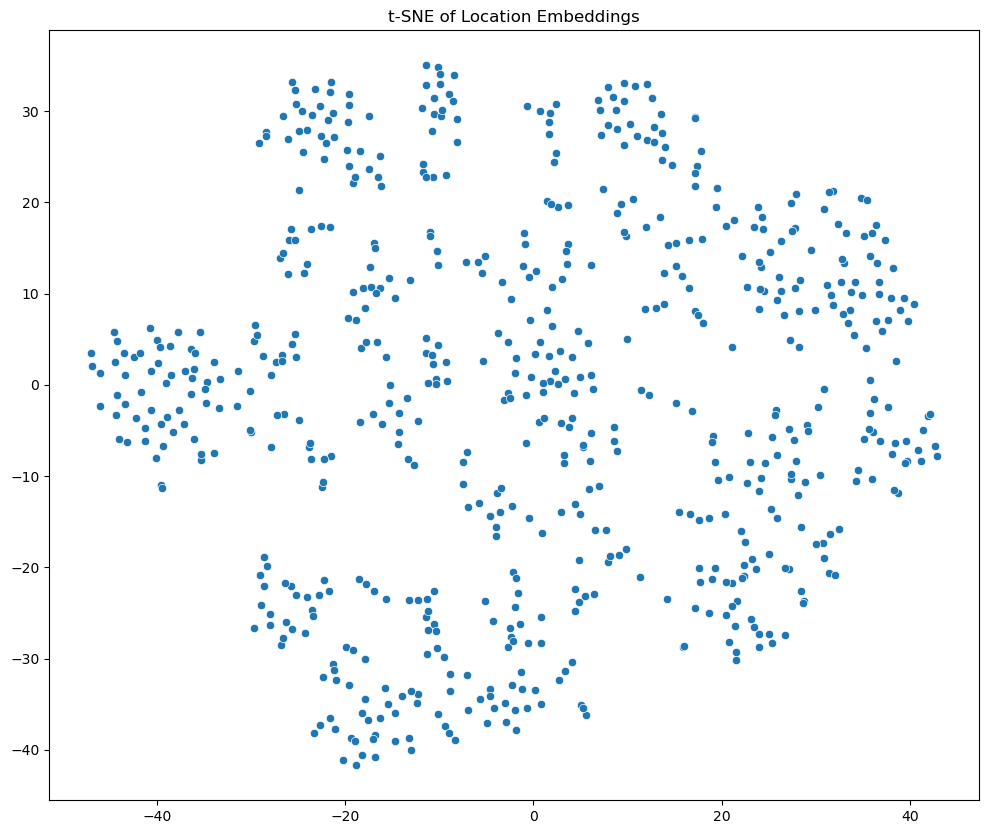

In [9]:
# # Get all place names and vectors
# places = list(model.wv.index_to_key)
# vectors = model.wv[places]

# # Reduce to 2D
# tsne = TSNE(n_components=2, random_state=42, perplexity=15)
# embeddings_2d = tsne.fit_transform(vectors)

# # Plot
# plt.figure(figsize=(12, 10))
# sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1])
# # for i, place in enumerate(places):
# #     plt.text(embeddings_2d[i,0], embeddings_2d[i,1], place, fontsize=8)
# plt.title("t-SNE of Location Embeddings")
# plt.show()

In [10]:
model.wv.most_similar('PARIS-20E-ARRONDISSEMENT', topn=5)

[('BAGNOLET', 0.7915846109390259),
 ('LES LILAS', 0.7222108840942383),
 ('SAINT-MAURICE', 0.717563807964325),
 ('PARIS-11E-ARRONDISSEMENT', 0.7135478854179382),
 ('PARIS-19E-ARRONDISSEMENT', 0.6840278506278992)]

## With UMAP

Each point is a location
Proximity between points = similarity in mobility behavior (based on trajectories)
Clusters = groups of areas that often appear together in sequences (e.g. daily routines)


>UMAP may better preserve the overall structure, showing clearer cluster shapes and distances between them  
>UMAP is faster and more scalable than t-SNE for large data

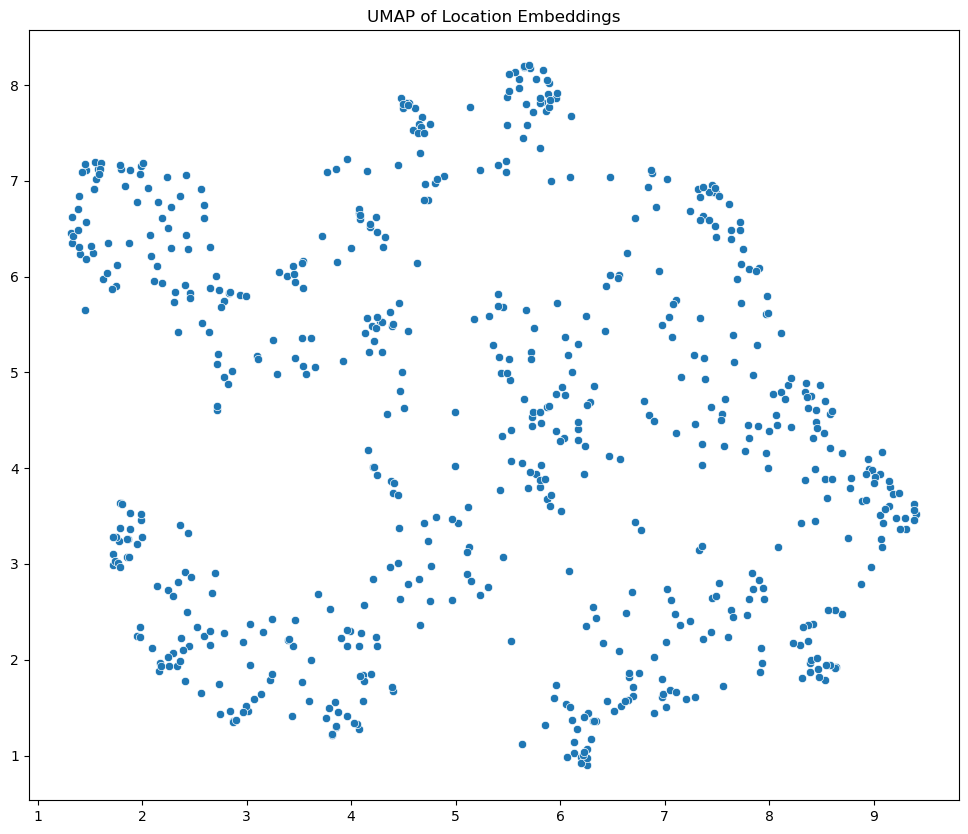

In [11]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=1)
embeddings_umap = reducer.fit_transform(vectors)

plt.figure(figsize=(12, 10))
sns.scatterplot(x=embeddings_umap[:, 0], y=embeddings_umap[:, 1])
plt.title('UMAP of Location Embeddings')
plt.show()

# Color embeddings by profession

In [14]:
from collections import defaultdict

# Initialize dictionary: location -> list of PRO_CATs
location_procat = defaultdict(list)

# Go through the trajectories to collect PRO_CAT for each location
for trajectory, (person_id, _) in zip(trajectories, trips_grouped.groups.keys()):
    procat = id_to_procat.get(person_id)
    if procat is not None:
        for location in trajectory:
            location_procat[location].append(procat)


In [15]:
location_dominant_procat = {
    location: Counter(procats).most_common(1)[0][0]
    for location, procats in location_procat.items()
}

# Map PRO_CAT to colors
unique_procats = sorted(set(location_dominant_procat.values()))
procat_to_color = {procat: i for i, procat in enumerate(unique_procats)}

# Generate color list aligned with places
colors = [procat_to_color.get(location_dominant_procat.get(place, None), -1) for place in places]


NameError: name 'places' is not defined

In [21]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=embeddings_2d[:,0],
    y=embeddings_2d[:,1],
    hue=[unique_procats[c] if c != -1 else "Unknown" for c in colors],
    palette='tab10',
    legend='full'
)
plt.title("t-SNE of Location Embeddings Colored by PRO_CAT")
plt.legend(title="PRO_CAT", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


ValueError: All arrays must be of the same length

<Figure size 1200x1000 with 0 Axes>

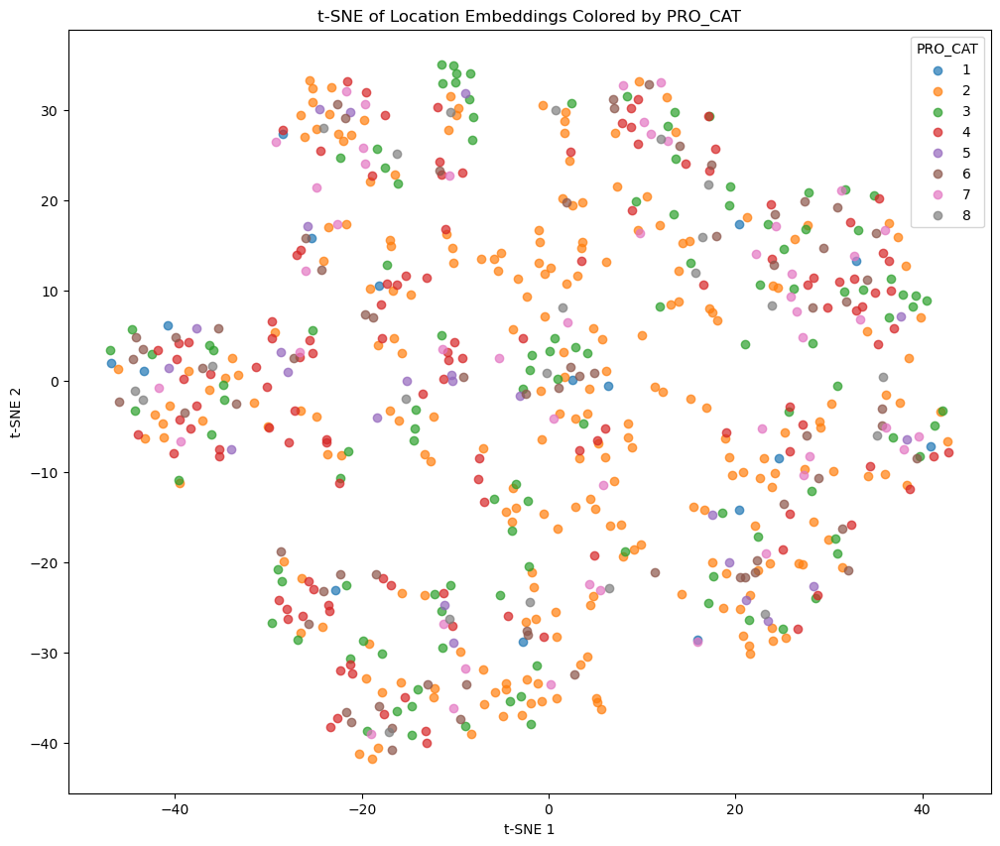

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings_2d = tsne.fit_transform(vectors)

# Get unique PRO_CATs and map to colors
unique_procats = sorted(set(location_dominant_procat.values()))
procat_to_color = {procat: i for i, procat in enumerate(unique_procats)}

# Assign a color index per location, fallback to -1 if unknown
colors = [procat_to_color.get(location_dominant_procat.get(place, None), -1) for place in places]

# Convert to numpy array for easier masking
colors = np.array(colors)

plt.figure(figsize=(12, 10))

# Plot known PRO_CAT points
for i, procat in enumerate(unique_procats):
    idx = colors == i
    plt.scatter(embeddings_2d[idx, 0], embeddings_2d[idx, 1], label=procat, alpha=0.7)

# Plot unknown as gray (optional)
unknown_idx = colors == -1
if unknown_idx.any():
    plt.scatter(embeddings_2d[unknown_idx, 0], embeddings_2d[unknown_idx, 1], color='gray', label='Unknown', alpha=0.5)

plt.legend(title='PRO_CAT')
plt.title("t-SNE of Location Embeddings Colored by PRO_CAT")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


# Places → Clusters

In [16]:
from sklearn.cluster import KMeans

n_clusters = 10  # you choose
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
place_clusters = kmeans.fit_predict(model.wv.vectors)

# Map each place to its cluster
place_to_cluster = dict(zip(model.wv.index_to_key, place_clusters))
place_to_cluster

{'PARIS-13E-ARRONDISSEMENT': 6,
 'PARIS-12E-ARRONDISSEMENT': 4,
 'PARIS-15E-ARRONDISSEMENT': 4,
 'PARIS-19E-ARRONDISSEMENT': 4,
 'PARIS-20E-ARRONDISSEMENT': 4,
 'PARIS-14E-ARRONDISSEMENT': 8,
 'PARIS-11E-ARRONDISSEMENT': 4,
 'MONTREUIL': 4,
 'EVRY': 0,
 'PARIS-18E-ARRONDISSEMENT': 4,
 'PARIS-16E-ARRONDISSEMENT': 4,
 'PARIS-10E-ARRONDISSEMENT': 4,
 'PARIS-9E-ARRONDISSEMENT': 4,
 'PARIS-17E-ARRONDISSEMENT': 4,
 'PARIS-5E-ARRONDISSEMENT': 4,
 'BOULOGNE-BILLANCOURT': 8,
 'SAINT-DENIS': 4,
 'PUTEAUX': 4,
 'ISSY-LES-MOULINEAUX': 8,
 'PARIS-8E-ARRONDISSEMENT': 4,
 'PARIS-4E-ARRONDISSEMENT': 4,
 'CERGY': 9,
 'PARIS-1ER-ARRONDISSEMENT': 4,
 'NANTERRE': 4,
 'PARIS-7E-ARRONDISSEMENT': 4,
 'VERSAILLES': 2,
 'CRETEIL': 6,
 'PARIS-6E-ARRONDISSEMENT': 4,
 'PANTIN': 4,
 'SAINT-OUEN': 4,
 'NOISY-LE-GRAND': 3,
 'ARGENTEUIL': 9,
 'COURBEVOIE': 4,
 'RUEIL-MALMAISON': 2,
 'MAISONS-ALFORT': 6,
 'PARIS-2E-ARRONDISSEMENT': 4,
 'AULNAY-SOUS-BOIS': 5,
 'ANTONY': 8,
 'VINCENNES': 4,
 'MELUN': 1,
 'MASSY': 8,
 'C

In [17]:
filtered_df['Cluster_O'] = filtered_df['Area_O'].map(place_to_cluster)
filtered_df['Cluster_D'] = filtered_df['Area_D'].map(place_to_cluster)
filtered_df

,ID,Date_EMG,KEY,Day_EMG,Day_Type,ID_Trip_Days,Type_Trip_OD,Area_O,Area_D,Code_INSEE_O,...,Purpose_D,Main_Mode,Mode_1,Mode_2,Mode_3,Mode_4,Mode_5,Weight_Day,Cluster_O,Cluster_D
0,10_2978,2023-03-15,10_2978-wednesday-45000-1,wednesday,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683,2,2
1,10_2978,2023-03-15,10_2978-wednesday-45000-2,wednesday,Normal,2,Internal,BOUGIVAL,BOUGIVAL,78092,...,RETURN_HOME,WALKING,WALKING,NaN,NaN,NaN,NaN,235.905683,2,2
2,10_2978,2023-03-15,10_2978-wednesday-45000-3,wednesday,Normal,3,Internal,BOUGIVAL,LE CHESNAY,78092,...,ACCOM,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683,2,2
3,10_2978,2023-03-15,10_2978-wednesday-45000-4,wednesday,Normal,4,Internal,LE CHESNAY,BOUGIVAL,78158,...,RETURN_HOME,PRIV_CAR_DRIVER,PRIV_CAR_DRIVER,NaN,NaN,NaN,NaN,235.905683,2,2
4,10_2978,2023-03-16,10_2978-thursday-45001-1,thursday,Normal,1,Internal,BOUGIVAL,BOUGIVAL,78092,...,OTHER,WALKING,WALKING,NaN,NaN,NaN,NaN,218.345882,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74738,7_2976,2023-02-15,7_2976-wednesday-44972-2,wednesday,Normal,2,Internal,IVRY-SUR-SEINE,VITRY-SUR-SEINE,94041,...,RETURN_HOME,ELECT_SCOOTER,ELECT_SCOOTER,NaN,NaN,NaN,NaN,67.357451,6,6
74739,7_2976,2023-02-17,7_2976-friday-44974-1,friday,Normal,1,Internal,VITRY-SUR-SEINE,SAINT-AUBIN,94081,...,WORK,BUS,BUS,NaN,NaN,NaN,NaN,67.548807,6,8
74740,7_2976,2023-02-17,7_2976-friday-44974-2,friday,Normal,2,Internal,SAINT-AUBIN,VITRY-SUR-SEINE,91538,...,RETURN_HOME,BUS,BUS,NaN,NaN,NaN,NaN,67.548807,8,6
74741,7_2976,2023-02-18,7_2976-saturday-44975-1,saturday,School holiday,1,Internal,VITRY-SUR-SEINE,PARIS-12E-ARRONDISSEMENT,94081,...,LEISURE,SUBWAY,SUBWAY,NaN,NaN,NaN,NaN,67.905299,6,4


# Individuals → Visiting Patterns

# Improvement
1. Tune t-SNE parameters: Try different perplexity values: default is 30, but sometimes 5-50 can help, Also, increase iterations for convergence (n_iter)
2. Use UMAP instead of t-SNE
3. Filter or zoom in on high-frequency tokens
4. Add color by metadata (profession), or Color points by day type, mode, or duration category
5. Consider more training tweaks for Word2Vec
    - Increase vector_size (e.g., 100 or 128)
    - Adjust window (context size), maybe try window=5
    - Train for more epochs (default is 5), add epochs=20
6. Use week instead of daily activity / would not have the day info

# With Qwen3-8 - Ollama

You can then use these vectors for:
- Semantic Search: Find sentences most similar to a query.
- Clustering: Group semantically similar sentences together.
- Classification: Train a classifier on top of these embeddings.

In [2]:
import ollama
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# Define the embedding model you pulled
EMBEDDING_MODEL = 'dengcao/Qwen3-Embedding-8B:Q5_K_M' # Or 4B, 0.6B

def get_sentence_embedding(text: str) -> list[float]:
    """Generates a numerical embedding vector for a given text."""
    try:
        # The 'embeddings' endpoint is specifically for this purpose
        response = ollama.embeddings(
            model=EMBEDDING_MODEL,
            prompt=text # Pass the sentence as the prompt
        )
        return response['embedding']
    except Exception as e:
        print(f"Error generating embedding for '{text}': {e}")
        return []

In [4]:
# Example sentences
sentences = [
    "The cat sat on the mat.",
    "A feline rested on the rug.",
    "The dog chased the ball in the park.",
    "Artificial intelligence is transforming industries.",
    "Machine learning algorithms power many modern applications."
]

# Get embeddings for each sentence
sentence_embeddings = []
for i, sentence in enumerate(sentences):
    print(f"Generating embedding for sentence {i+1}: '{sentence}'")
    embedding = get_sentence_embedding(sentence)
    if embedding:
        sentence_embeddings.append(np.array(embedding))
        print(f"  Embedding length: {len(embedding)}")
    else:
        sentence_embeddings.append(None)

# Filter out any failed embeddings
valid_embeddings = [emb for emb in sentence_embeddings if emb is not None]
valid_sentences = [sentences[i] for i, emb in enumerate(sentence_embeddings) if emb is not None]

Generating embedding for sentence 1: 'The cat sat on the mat.'
  Embedding length: 4096
Generating embedding for sentence 2: 'A feline rested on the rug.'
  Embedding length: 4096
Generating embedding for sentence 3: 'The dog chased the ball in the park.'
  Embedding length: 4096
Generating embedding for sentence 4: 'Artificial intelligence is transforming industries.'
  Embedding length: 4096
Generating embedding for sentence 5: 'Machine learning algorithms power many modern applications.'
  Embedding length: 4096


In [5]:
# Calculate and print similarities (e.g., cosine similarity)
if len(valid_embeddings) > 1:
    print("\n--- Semantic Relationships (Cosine Similarity) ---")
    for i in range(len(valid_embeddings)):
        for j in range(i + 1, len(valid_embeddings)):
            sim = cosine_similarity(
                valid_embeddings[i].reshape(1, -1),
                valid_embeddings[j].reshape(1, -1)
            )[0][0]
            print(f"Similarity between '{valid_sentences[i]}' and '{valid_sentences[j]}': {sim:.4f}")



--- Semantic Relationships (Cosine Similarity) ---
Similarity between 'The cat sat on the mat.' and 'A feline rested on the rug.': 0.6173
Similarity between 'The cat sat on the mat.' and 'The dog chased the ball in the park.': 0.3414
Similarity between 'The cat sat on the mat.' and 'Artificial intelligence is transforming industries.': 0.1585
Similarity between 'The cat sat on the mat.' and 'Machine learning algorithms power many modern applications.': 0.2090
Similarity between 'A feline rested on the rug.' and 'The dog chased the ball in the park.': 0.2875
Similarity between 'A feline rested on the rug.' and 'Artificial intelligence is transforming industries.': 0.1461
Similarity between 'A feline rested on the rug.' and 'Machine learning algorithms power many modern applications.': 0.2381
Similarity between 'The dog chased the ball in the park.' and 'Artificial intelligence is transforming industries.': 0.1595
Similarity between 'The dog chased the ball in the park.' and 'Machine le

In [26]:
# import ollama

# # Choose the model you pulled
# model_to_use = "qwen3:8b" # or "qwen3:30b-a3b"

# def generate_text(prompt):
#     try:
#         response = ollama.chat(
#             model=model_to_use,
#             messages=[{'role': 'user', 'content': prompt}],
#             stream=False # Set to True for streaming output
#         )
#         return response['message']['content']
#     except Exception as e:
#         return f"Error: {e}"

# print(generate_text("Explain the concept of 'unified memory' in Apple Silicon."))

<think>
Okay, the user is asking about 'unified memory' in Apple Silicon. Let me start by recalling what I know about this. Apple's M1 and later chips use a unified memory architecture, which is different from traditional memory systems. I remember that in traditional systems, there's separate memory for the CPU and GPU, but Apple's approach combines them into a single pool. 

First, I should explain what unified memory means in general. It's when the CPU, GPU, and other components share the same pool of memory. But how does that work in Apple's case? I think the key point is that all these components access the same memory, which is managed by the memory management unit (MMU) or something similar. 

Wait, Apple uses a memory management unit that handles how different components access the memory. So the CPU, GPU, and even the neural engine can all access the same memory space. That might improve performance because there's no need to transfer data between different memory spaces. 

I 